In [1]:
import pandas as pd

ratings = pd.read_csv("../../../../../../data/ml-20m/ratings.csv")
movies = pd.read_csv("../../../../../../data/ml-20m/movies.csv")

print(f"Ratings: {len(ratings):,} rows")
print(f"Unique users: {ratings['userId'].nunique():,}")
print(f"Unique rated movies: {ratings['movieId'].nunique():,}")
print(f"Sparsity: {1 - len(ratings) / (ratings['userId'].nunique() * ratings['movieId'].nunique()):.4%}")

# print((ratings['userId'].nunique() * ratings['movieId'].nunique()))
ratings.head()

Ratings: 20,000,263 rows
Unique users: 138,493
Unique rated movies: 26,744
Sparsity: 99.4600%


,userId,movieId,rating,timestamp
0,1,2,3.5,1112486027
1,1,29,3.5,1112484676
2,1,32,3.5,1112484819
3,1,47,3.5,1112484727
4,1,50,3.5,1112484580


In [2]:
ratings_per_user = ratings.groupby("userId").size()
ratings_per_movie = ratings.groupby("movieId").size()

print("Ratings per user:")
print(ratings_per_user.describe())
print()
print("Ratings per movie:")
print(ratings_per_movie.describe())

Ratings per user:
count    138493.000000
mean        144.413530
std         230.267257
min          20.000000
25%          35.000000
50%          68.000000
75%         155.000000
max        9254.000000
dtype: float64

Ratings per movie:
count    26744.000000
mean       747.841123
std       3085.818268
min          1.000000
25%          3.000000
50%         18.000000
75%        205.000000
max      67310.000000
dtype: float64


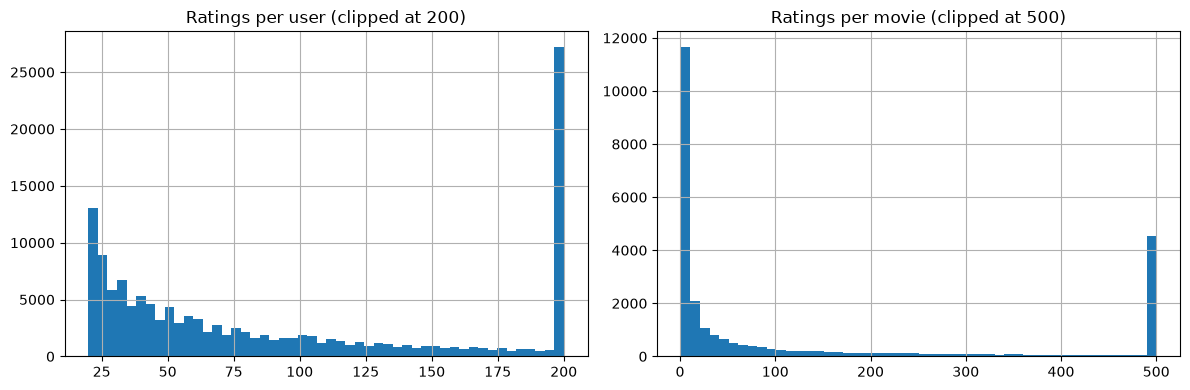

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ratings_per_user.clip(upper=200).hist(bins=50, ax=axes[0])
axes[0].set_title("Ratings per user (clipped at 200)")
ratings_per_movie.clip(upper=500).hist(bins=50, ax=axes[1])
axes[1].set_title("Ratings per movie (clipped at 500)")
plt.tight_layout()
plt.show()

In [4]:
movie_counts =  ratings.groupby("movieId").size()
valid_movies = movie_counts[movie_counts>=5].index
# print(movie_counts)
filtered_ratings = ratings[ratings["movieId"].isin(valid_movies)]
# print(filtered_ratings)
print(f"Movie before filter: {ratings['movieId'].nunique():,}")
print(f"Movie after filter: {filtered_ratings['movieId'].nunique():,}")
print(f"Ratings before filter: {len(ratings):,}")
print(f"Ratings after filter: {len(filtered_ratings):,}")

Movie before filter: 26,744
Movie after filter: 18,345
Ratings before filter: 20,000,263
Ratings after filter: 19,984,024


In [6]:
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy 

reader = Reader(rating_scale=(0.5,5.0))
data = Dataset.load_from_df(filtered_ratings[["userId", "movieId", "rating"]], reader)

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

model = SVD(n_factors=50, random_state=42)
model.fit(trainset)

predictions = model.test(testset)
rmse = accuracy.rmse(predictions)

RMSE: 0.7860


In [7]:
model_50 = SVD(
    n_factors=50,
    n_epochs=50,
    random_state=42
)

model_50.fit(trainset)

predictions_50 = model_50.test(testset)

rmse_50 = accuracy.rmse(predictions_50)

RMSE: 0.7873


In [8]:
from collections import defaultdict

def get_top_n(predictions, n=10):
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))

    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]

    return top_n

def precision_recall_at_k(predictions, k=10, threshold=3.5):
    user_est_true = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = {}
    recalls = {}
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)

        n_rel = sum(true_r >= threshold for (_, true_r) in user_ratings)
        n_rec_k = sum(est >= threshold for (est, _) in user_ratings)

        n_rel_and_rec_k = sum(true_r>= threshold and est >= threshold for (est, true_r) in user_ratings[:k])

        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0 
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

        return precisions, recalls

precisions, recalls = precision_recall_at_k(predictions, k=10, threshold=3.5)
avg_precision = sum(precisions.values()) / len(precisions)
avg_recall = sum(recalls.values()) / len(recalls)

print(f"Precision@k: {avg_precision:.4f} ")
print(f"Recall@k: {avg_recall:.4f} ")

Precision@k: 0.0422 
Recall@k: 0.0424 


In [ ]:
import random

random.seed(42)

all_movie_ids = set(filtered_ratings["movieid"].unique())
user_rated = defaultdict(set)

for uid, mid in zip(filtered_ratings["userId", filtered_ratings["movieId"]]):
    user_rated[uid].add(mid)

def sampled_hit_rate_at_k(predictions, k=10, n_negatives = 99, threshold = 3.5):
    hits = 0
    total = 0

    positives = [(uid, iid) for uid, iid, true_r, _, _ in predictions]

    for uid, true_iid in positives:
        unrated_pool = list(all_movie_ids - user_rated[uid])
        if len(unrated_pool) < n_negatives:
            continue

        negatives = random.sample(unrated_pool, n_negatives)
        candidates = negatives + [true_iid]